# 06. ¿Qué variables de sentimiento ayudan o perjudican?

**Autor: Marco Padilla Gómez.** Ampliación exploratoria de la issue #48.

La primera ronda añadió cinco variables simultáneamente. Este cuaderno separa sus
efectos: las añade una a una a la referencia sin extras y las retira una a una del
bloque completo. No sobrescribe experimentos anteriores ni cambia los modelos finales.

**Importante:** estos periodos ya se han examinado. Los resultados no constituyen
una prueba independiente y no demuestran rentabilidad.


## 1. Referencias y controles

Tres algoritmos, cuatro empresas, tres bloques externos y 553 sesiones por empresa.
Se mantienen fechas, etiquetas, noticias depuradas, historial, purga temporal y umbral 0,5.
Los hiperparámetros se heredan de cada referencia y bloque; fueron seleccionados
con validación temporal interna, pero aquí no se vuelven a optimizar.

En el híbrido con retardo se estudia la familia **variable actual + retardo de una sesión**.
No se mide por separado el efecto de cada componente. La base financiera no cambia.
Son 180 modelos nuevos y 36 referencias verificadas.


In [1]:
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'src').is_dir(), 'Ejecuta desde la raíz o notebooks/'
sys.path.insert(0, str(ROOT))
from src.experiments.run_per_company import verify_pairing
from sklearn.metrics import roc_auc_score

RUN = ROOT / 'reports/experiments/variable-ablation-full-20260917'
manifest = json.loads((RUN / 'manifest.json').read_text(encoding='utf-8'))
assert manifest['status'] == 'complete'
for relative, digest in manifest['output_sha256'].items():
    if relative.startswith(RUN.relative_to(ROOT).as_posix() + '/'):
        assert hashlib.sha256((ROOT / relative).read_bytes()).hexdigest() == digest
predictions = pd.read_csv(RUN / 'predictions/all_predictions.csv', parse_dates=['Date'], float_precision='round_trip')
metrics = pd.read_csv(RUN / 'metrics/macro_metrics.csv')
companies = pd.read_csv(RUN / 'metrics/company_metrics.csv')
intervals = pd.read_csv(RUN / 'metrics/paired_intervals.csv')
macro = intervals[intervals.ticker == 'macro'].copy()
macro['mode'] = macro.approach.str.split('_', n=1).str[0]
macro['feature'] = macro.approach.str.split('_', n=1).str[1]
assert len(predictions) == 159264 and len(macro) == 60 and len(intervals) == 300
for candidate, reference in manifest['config']['contrasts']:
    verify_pairing(predictions[predictions.approach == candidate], predictions[predictions.approach == reference])
for (approach, variant, model), part in predictions.groupby(['approach', 'dataset_type', 'model_name']):
    observed = np.mean([roc_auc_score(p.target, p.probability) for _, p in part.groupby('ticker')])
    saved = metrics[(metrics.approach == approach) & (metrics.dataset_type == variant) & (metrics.model_name == model)].roc_auc.iloc[0]
    assert np.isclose(observed, saved, atol=1e-14, rtol=0)
print('Informes, emparejamiento y AUC verificados. No se entrena ni se consulta ninguna API.')
display(predictions.groupby('ticker').agg(sesiones=('Date', 'nunique'), inicio=('Date', 'min'), fin=('Date', 'max')))


Informes, emparejamiento y AUC verificados. No se entrena ni se consulta ninguna API.


,sesiones,inicio,fin
ticker,,,
AAPL,553,2023-10-16,2025-12-29
MSFT,553,2023-10-16,2025-12-29
NVDA,553,2023-10-16,2025-12-29
TSLA,553,2023-10-16,2025-12-29


## 2. Las cinco variables

| Variable | Significado |
| --- | --- |
| Dispersión | Desviación típica del tono de las noticias de la sesión. |
| Intensidad absoluta | Media del valor absoluto del sentimiento. |
| Sorpresa del sentimiento | Diferencia respecto al tono histórico de las 20 sesiones anteriores. |
| Historia disponible | Indica que existen al menos cinco observaciones de tono en esa ventana. |
| Sorpresa del volumen | Volumen logarítmico de noticias estandarizado respecto a las 20 sesiones anteriores. |

Las referencias históricas excluyen siempre la sesión actual. Ausencia de noticias
registradas no equivale a ausencia de noticias reales.


In [2]:
LABELS = {'news_sentiment_std': 'Dispersión del sentimiento', 'news_abs_sentiment': 'Intensidad absoluta', 'sentiment_surprise_20': 'Sorpresa del sentimiento', 'sentiment_history_ready': 'Historia disponible', 'news_log_surprise_20': 'Sorpresa del volumen de noticias'}
MODELS = {'logistic_regression': 'Regresión logística', 'random_forest': 'Bosque aleatorio', 'hist_gradient_boosting': 'Potenciación por histogramas'}
anchors = metrics[metrics.approach.isin(['deduplicated', 'enhanced'])].pivot(
    index=['dataset_type', 'model_name'], columns='approach', values='roc_auc')
display(anchors.rename(columns={'deduplicated': 'Sin extras', 'enhanced': 'Bloque completo'}).round(6))


approach                             Sin extras  Bloque completo
dataset_type model_name                                         
hybrid       hist_gradient_boosting    0.514705         0.506631
             logistic_regression       0.497700         0.497144
             random_forest             0.504481         0.510126
lag_1        hist_gradient_boosting    0.517173         0.499149
             logistic_regression       0.497372         0.496009
             random_forest             0.509038         0.506838

## 3. Resumen descriptivo

Se presenta el cambio de AUC macro, promediado entre los tres algoritmos. No es
un ensemble ni una estimación con intervalo propio. Un cambio positivo al añadir
sugiere utilidad; positivo al retirar sugiere perjuicio en el bloque completo.
Consulte después los algoritmos por separado: el promedio puede ocultar diferencias.


In [3]:
summary = macro.groupby(['feature', 'mode', 'dataset_type']).auc_delta.mean().unstack(['mode', 'dataset_type'])
summary = summary.reindex(LABELS).rename(index=LABELS)
display(summary.round(6))


mode                                   add                drop          
dataset_type                        hybrid     lag_1    hybrid     lag_1
feature                                                                 
Dispersión del sentimiento        0.002037 -0.004899  0.000015  0.002836
Intensidad absoluta               0.003609 -0.002369  0.002242  0.001187
Sorpresa del sentimiento          0.001186 -0.003151 -0.000233  0.001029
Historia disponible               0.001750 -0.000591 -0.000290 -0.000543
Sorpresa del volumen de noticias  0.006484 -0.001424  0.001661  0.002466

## 4. Añadir y retirar, algoritmo por algoritmo

Cada celda muestra la diferencia frente a su propia referencia, no el AUC absoluto.
Rojo indica empeoramiento y verde mejora. No se debe interpretar un color como
significación estadística. En retardo se cambia la familia de dos columnas.


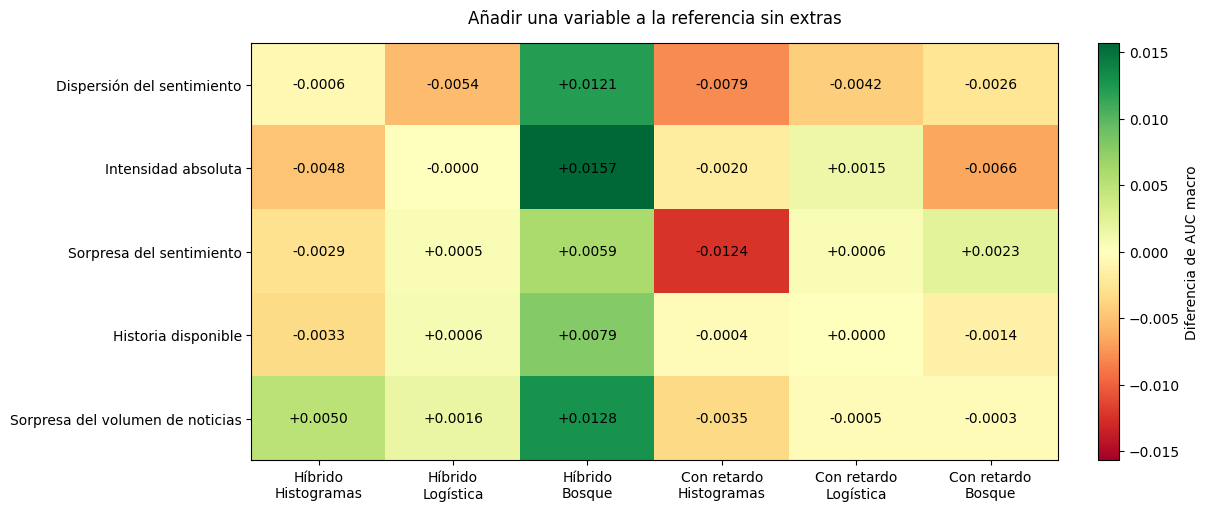

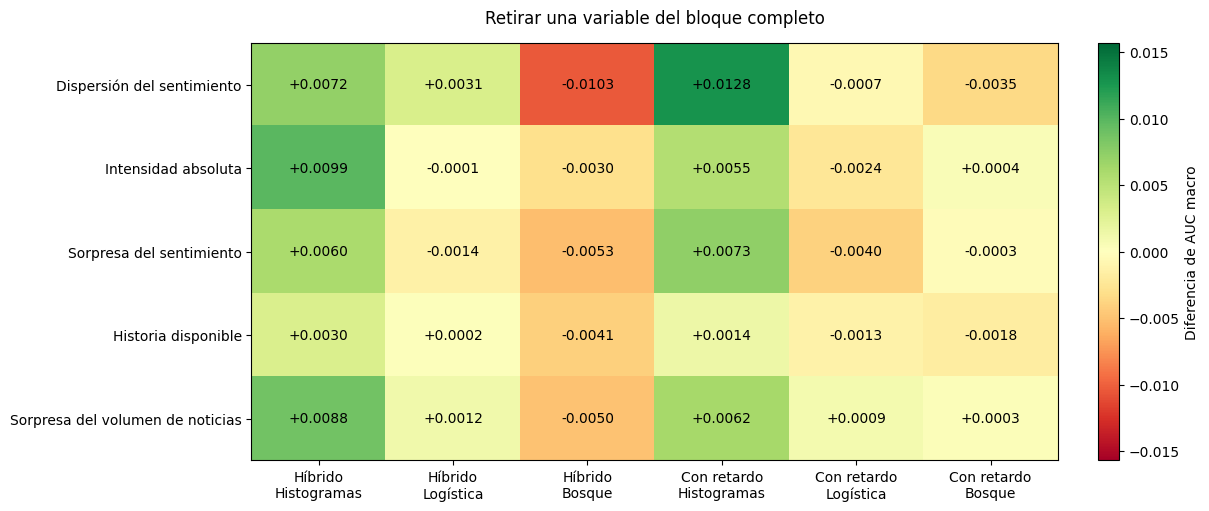

In [4]:
for mode, title in [('add', 'Añadir una variable a la referencia sin extras'), ('drop', 'Retirar una variable del bloque completo')]:
    table = macro[macro['mode'] == mode].pivot(index='feature', columns=['dataset_type', 'model_name'], values='auc_delta').reindex(LABELS)
    fig, ax = plt.subplots(figsize=(12, 5), layout='constrained')
    limit = max(abs(macro.auc_delta).max(), 0.001)
    im = ax.imshow(table.to_numpy(), cmap='RdYlGn', vmin=-limit, vmax=limit, aspect='auto')
    ax.set_yticks(range(len(table)), [LABELS[v] for v in table.index])
    short = {'hist_gradient_boosting': 'Histogramas', 'logistic_regression': 'Logística', 'random_forest': 'Bosque'}
    ax.set_xticks(range(len(table.columns)), [('Híbrido' if v == 'hybrid' else 'Con retardo') + '\n' + short[m] for v, m in table.columns])
    for i in range(len(table)):
        for j in range(len(table.columns)):
            ax.text(j, i, f'{table.iloc[i, j]:+.4f}', ha='center', va='center', fontsize=10)
    ax.set_title(title, pad=14)
    fig.colorbar(im, ax=ax, label='Diferencia de AUC macro')
    plt.show()


## 5. Incertidumbre y resultados completos

Intervalos del 95 %: bootstrap pareado por bloques móviles de 20 fechas, 1.000
réplicas, sin reajustar modelos. No hay corrección por comparaciones múltiples.
Las 15 adiciones al híbrido son primarias; los otros 45 contrastes son secundarios.
Un intervalo que contiene cero no permite distinguir la diferencia de cero con
este procedimiento. Tampoco prueba equivalencia.


In [5]:
columns = ['approach', 'dataset_type', 'model_name', 'reference_auc', 'roc_auc', 'auc_delta', 'delta_low', 'delta_high']
for mode, title in [('add', 'Añadir'), ('drop', 'Retirar')]:
    print(title)
    with pd.option_context('display.max_rows', 40):
        display(macro.loc[macro['mode'] == mode, columns].round(6))
nominal = macro[(macro.delta_low > 0) | (macro.delta_high < 0)]
print('Contrastes macro con intervalo que no contiene cero (sin corregir):', len(nominal), 'de', len(macro))
display(nominal[columns].round(6))


Añadir


,approach,dataset_type,model_name,reference_auc,roc_auc,auc_delta,delta_low,delta_high
4,add_news_sentiment_std,hybrid,hist_gradient_boosting,0.514705,0.514085,-0.000620,-0.014170,0.010694
9,add_news_sentiment_std,hybrid,logistic_regression,0.497700,0.492333,-0.005367,-0.015110,0.008172
14,add_news_sentiment_std,hybrid,random_forest,0.504481,0.516580,0.012099,-0.002238,0.023349
19,add_news_sentiment_std,lag_1,hist_gradient_boosting,0.517173,0.509274,-0.007898,-0.022886,0.002218
24,add_news_sentiment_std,lag_1,logistic_regression,0.497372,0.493131,-0.004241,-0.013612,0.007762
29,add_news_sentiment_std,lag_1,random_forest,0.509038,0.506478,-0.002560,-0.015804,0.012918
34,add_news_abs_sentiment,hybrid,hist_gradient_boosting,0.514705,0.509864,-0.004841,-0.020400,0.009886
39,add_news_abs_sentiment,hybrid,logistic_regression,0.497700,0.497656,-0.000044,-0.002567,0.003557
44,add_news_abs_sentiment,hybrid,random_forest,0.504481,0.520192,0.015711,0.000408,0.026242
49,add_news_abs_sentiment,lag_1,hist_gradient_boosting,0.517173,0.515220,-0.001953,-0.019248,0.010636


Retirar


,approach,dataset_type,model_name,reference_auc,roc_auc,auc_delta,delta_low,delta_high
154,drop_news_sentiment_std,hybrid,hist_gradient_boosting,0.506631,0.513863,0.007232,-0.006754,0.019636
159,drop_news_sentiment_std,hybrid,logistic_regression,0.497144,0.500272,0.003128,-0.006342,0.013443
164,drop_news_sentiment_std,hybrid,random_forest,0.510126,0.499811,-0.010315,-0.022347,0.002140
169,drop_news_sentiment_std,lag_1,hist_gradient_boosting,0.499149,0.511940,0.012790,-0.001470,0.028507
174,drop_news_sentiment_std,lag_1,logistic_regression,0.496009,0.495276,-0.000734,-0.007557,0.009091
179,drop_news_sentiment_std,lag_1,random_forest,0.506838,0.503289,-0.003549,-0.016157,0.008051
184,drop_news_abs_sentiment,hybrid,hist_gradient_boosting,0.506631,0.516490,0.009859,-0.002704,0.025761
189,drop_news_abs_sentiment,hybrid,logistic_regression,0.497144,0.497030,-0.000114,-0.001803,0.003206
194,drop_news_abs_sentiment,hybrid,random_forest,0.510126,0.507107,-0.003019,-0.012419,0.008653
199,drop_news_abs_sentiment,lag_1,hist_gradient_boosting,0.499149,0.504669,0.005519,-0.006564,0.019400


Contrastes macro con intervalo que no contiene cero (sin corregir): 1 de 60


,approach,dataset_type,model_name,reference_auc,roc_auc,auc_delta,delta_low,delta_high
44,add_news_abs_sentiment,hybrid,random_forest,0.504481,0.520192,0.015711,0.000408,0.026242


## 6. Heterogeneidad por empresa y bloque

Se muestran los cambios de los 15 contrastes primarios por empresa y los cambios
por bloque promediados entre empresas. Permiten comprobar si el resultado agregado
se concentra en una compañía o periodo; no son nuevos criterios para seleccionar
automáticamente el mejor modelo.


In [6]:
individual = intervals[(intervals.ticker != 'macro') & intervals.approach.str.startswith('add_') & (intervals.dataset_type == 'hybrid')]
display(individual.pivot(index=['approach', 'model_name'], columns='ticker', values='auc_delta').round(6))
all_metrics = pd.read_csv(RUN / 'metrics/all_metrics.csv')
folds = all_metrics[all_metrics.scope == 'outer_fold'].groupby(['approach', 'dataset_type', 'model_name', 'group']).roc_auc.mean().reset_index()
reference = folds[folds.approach == 'deduplicated'].drop(columns='approach').rename(columns={'roc_auc': 'reference_auc'})
primary_folds = folds[folds.approach.str.startswith('add_') & (folds.dataset_type == 'hybrid')].merge(reference, on=['dataset_type', 'model_name', 'group'], validate='many_to_one')
primary_folds['delta'] = primary_folds.roc_auc - primary_folds.reference_auc
display(primary_folds.pivot(index=['approach', 'model_name'], columns='group', values='delta').round(6))


ticker                                                  AAPL      MSFT  \
approach                    model_name                                   
add_news_abs_sentiment      hist_gradient_boosting  0.004271 -0.017088   
                            logistic_regression    -0.003111  0.001229   
                            random_forest           0.029650 -0.007979   
add_news_log_surprise_20    hist_gradient_boosting  0.039828  0.003554   
                            logistic_regression     0.010547  0.000713   
                            random_forest           0.024416  0.000713   
add_news_sentiment_std      hist_gradient_boosting  0.000633  0.001163   
                            logistic_regression     0.014515  0.000053   
                            random_forest           0.021595 -0.017504   
add_sentiment_history_ready hist_gradient_boosting -0.003204 -0.004201   
                            logistic_regression    -0.000448 -0.001149   
                            random_forest           0.015728 -0.023502   
add_sentiment_surprise_20   hist_gradient_boosting  0.002577  0.008078   
                            logistic_regression     0.001819  0.000594   
                            random_forest           0.013632 -0.010938   

ticker                                                  NVDA      TSLA  
approach                    model_name                                  
add_news_abs_sentiment      hist_gradient_boosting -0.004743 -0.001806  
                            logistic_regression     0.001863 -0.000157  
                            random_forest           0.032512  0.008664  
add_news_log_surprise_20    hist_gradient_boosting -0.017299 -0.005968  
                            logistic_regression    -0.005773  0.000929  
                            random_forest           0.027571 -0.001427  
add_news_sentiment_std      hist_gradient_boosting  0.001863 -0.006138  
                            logistic_regression    -0.018891 -0.017144  
                            random_forest           0.050927 -0.006622  
add_sentiment_history_ready hist_gradient_boosting -0.000674 -0.005274  
                            logistic_regression     0.002840  0.001335  
                            random_forest           0.028971  0.010575  
add_sentiment_surprise_20   hist_gradient_boosting  0.002926 -0.025062  
                            logistic_regression     0.000225 -0.000497  
                            random_forest           0.013435  0.007447

group                                                    1.0       2.0  \
approach                    model_name                                   
add_news_abs_sentiment      hist_gradient_boosting  0.015528 -0.022726   
                            logistic_regression     0.000491  0.001163   
                            random_forest           0.008221  0.004659   
add_news_log_surprise_20    hist_gradient_boosting  0.001583 -0.000318   
                            logistic_regression     0.003328  0.004185   
                            random_forest           0.011946 -0.007901   
add_news_sentiment_std      hist_gradient_boosting  0.013455  0.008615   
                            logistic_regression    -0.001324  0.003837   
                            random_forest           0.011804  0.006438   
add_sentiment_history_ready hist_gradient_boosting -0.005039  0.000000   
                            logistic_regression     0.000877 -0.000559   
                            random_forest           0.003936 -0.008343   
add_sentiment_surprise_20   hist_gradient_boosting  0.026897 -0.006625   
                            logistic_regression     0.005845 -0.001888   
                            random_forest          -0.006773  0.007480   

group                                                    3.0  
approach                    model_name                        
add_news_abs_sentiment      hist_gradient_boosting -0.007328  
                            logistic_regression     0.000480  
                            random_forest           0.035597  
add_news_log_surprise_20    hist_gradient_boosting  0.015445  
                            logistic_regression    -0.004501  
                            random_forest           0.032126  
add_news_sentiment_std      hist_gradient_boosting -0.016928  
                            logistic_regression    -0.015885  
                            random_forest           0.017588  
add_sentiment_history_ready hist_gradient_boosting -0.001108  
                            logistic_regression     0.002685  
                            random_forest           0.023782  
add_sentiment_surprise_20   hist_gradient_boosting -0.026143  
                            logistic_regression     0.003567  
                            random_forest           0.013812

## 7. Conclusión y límites

**Resultados concretos:** la sorpresa del volumen mejora los tres híbridos sin
retardo (promedio de diferencias +0,006484), pero no los modelos con retardo.
La intensidad absoluta eleva el bosque híbrido de 0,504481 a 0,520192; su diferencia
tiene intervalo [0,000408; 0,026242], el único macro que no contiene cero entre
60 contrastes sin corrección. El intervalo de su AUC aún contiene 0,5.
La dispersión añadida con su retardo registra la mayor caída media (-0,004899).
Las cinco adiciones con retardo empeoran en promedio entre algoritmos.
Ninguna retirada del bloque completo muestra un intervalo macro que excluya cero.

La utilidad de una variable depende del algoritmo y de las otras variables presentes.
Añadir y retirar no son operaciones simétricas: cambian el contexto y pueden partir
de hiperparámetros distintos. Cambiar el número de columnas también afecta al muestreo
de variables del bosque. Esta ablación no permite atribuir efectos causales.

Las diferencias pequeñas, los intervalos y la repetida consulta de estos periodos
impiden afirmar una mejora robusta por un máximo aislado. Una combinación escogida
a partir de estas tablas necesitaría validación nueva. No se modifica `reports/final/`.

El [informe completo](../reports/experiments/variable-ablation-full-20260917/analysis.md)
recoge las cifras; el [protocolo](../docs/variable_ablation_protocol.md) documenta
las decisiones previas. Las métricas de clasificación adicionales están en
`metrics/macro_metrics.csv` y `metrics/company_metrics.csv`.
